<a href="https://colab.research.google.com/github/navvod/IT4060-ML-Assignment/blob/main/04_KNN_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔵 Crop Recommendation — Algorithm 3: K-Nearest Neighbors (KNN)

**Dataset:** Crop Recommendation Dataset  
**Source:** https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset  
**Type:** Supervised Learning — Multi-class Classification  
**Algorithm:** K-Nearest Neighbors Classifier  

---

In [ ]:
# ── CELL 1 — Import Libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [ ]:
# ── CELL 2 — Load Dataset ──────────────────────────────────────────────────
df = pd.read_csv('/content/Crop_recommendation.csv')
print(f'✅ Dataset loaded!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded!
Shape: 2200 rows × 8 columns


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
# ── CELL 3 — Prepare Features & Target ────────────────────────────────────
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'Features shape : {X.shape}')
print(f'Target classes : {len(le.classes_)}')
print(f'Classes        : {list(le.classes_)}')

Features shape : (2200, 7)
Target classes : 22
Classes        : ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [ ]:
# ── CELL 4 — Feature Scaling (IMPORTANT for KNN) ──────────────────────────
# KNN is distance-based, so features MUST be scaled.
# Without scaling, large-range features (e.g. rainfall) dominate the distance.

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('✅ Features scaled with StandardScaler!')
print('Before scaling (mean, std):')
print(X.describe().loc[['mean','std']].round(2))
print('\nAfter scaling (mean, std):')
print(X_scaled.describe().loc[['mean','std']].round(4))

✅ Features scaled with StandardScaler!
Before scaling (mean, std):
          N      P      K  temperature  humidity    ph  rainfall
mean  50.55  53.36  48.15        25.62     71.48  6.47    103.46
std   36.92  32.99  50.65         5.06     22.26  0.77     54.96

After scaling (mean, std):
           N       P       K  temperature  humidity      ph  rainfall
mean -0.0000  0.0000 -0.0000       0.0000   -0.0000 -0.0000    0.0000
std   1.0002  1.0002  1.0002       1.0002    1.0002  1.0002    1.0002


In [ ]:
# ── CELL 5 — Train / Test Split ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Split ratio  : 80% train / 20% test')

Training set : 1760 samples
Test set     : 440 samples
Split ratio  : 80% train / 20% test


Best K (highest test accuracy) : k = 1
Test accuracy at best K        : 0.9795


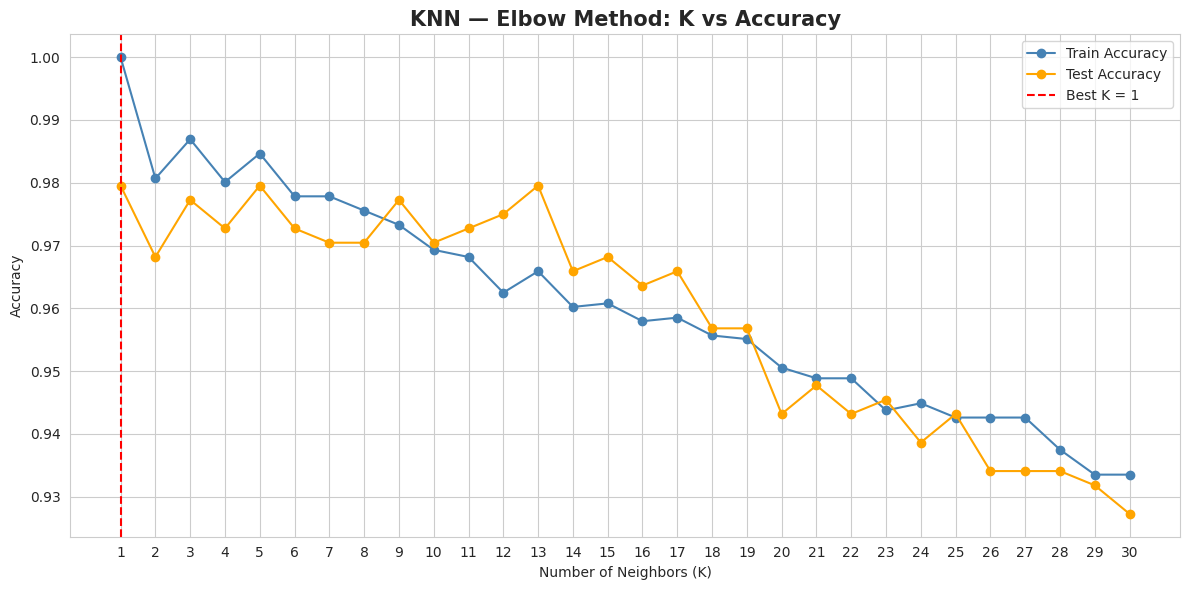

In [ ]:
# ── CELL 6 — Find Best K (Elbow Method) ───────────────────────────────────
# Try k from 1 to 30 and plot train vs test accuracy
k_range     = range(1, 31)
train_accs  = []
test_accs   = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  knn.predict(X_test)))

best_k = k_range[np.argmax(test_accs)]
print(f'Best K (highest test accuracy) : k = {best_k}')
print(f'Test accuracy at best K        : {max(test_accs):.4f}')

plt.figure(figsize=(12, 6))
plt.plot(k_range, train_accs, 'o-', color='steelblue', label='Train Accuracy')
plt.plot(k_range, test_accs,  'o-', color='orange',    label='Test Accuracy')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.title('KNN — Elbow Method: K vs Accuracy', fontsize=15, fontweight='bold')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 7 — Hyperparameter Tuning with GridSearchCV ──────────────────────
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n✅ Best Parameters : {grid_search.best_params_}')
print(f'Best CV Accuracy   : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 120 candidates, totalling 600 fits

✅ Best Parameters : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best CV Accuracy   : 0.9812


In [ ]:
# ── CELL 8 — Best Model ───────────────────────────────────────────────────
best_knn = grid_search.best_estimator_

print('✅ Best KNN model ready!')
print(f'Best K       : {best_knn.n_neighbors}')
print(f'Weights      : {best_knn.weights}')
print(f'Distance     : {best_knn.metric}')

✅ Best KNN model ready!
Best K       : 5
Weights      : distance
Distance     : manhattan


In [ ]:
# ── CELL 9 — Predictions ──────────────────────────────────────────────────
y_pred       = best_knn.predict(X_test)
y_pred_proba = best_knn.predict_proba(X_test)

print('✅ Predictions generated!')
print(f'Sample predictions (encoded) : {y_pred[:10]}')
print(f'Sample predictions (labels)  : {list(le.inverse_transform(y_pred[:10]))}')

✅ Predictions generated!
Sample predictions (encoded) : [16  1  6 11 19  3 20  2  1 16]
Sample predictions (labels)  : ['orange', 'banana', 'cotton', 'maize', 'pomegranate', 'chickpea', 'rice', 'blackgram', 'banana', 'orange']


In [ ]:
# ── CELL 10 — Cross Validation ────────────────────────────────────────────
cv_scores = cross_val_score(best_knn, X_scaled, y_encoded, cv=10, scoring='accuracy')

print('=== 10-Fold Cross Validation ===')
print(f'Scores  : {np.round(cv_scores, 4)}')
print(f'Mean    : {cv_scores.mean():.4f}')
print(f'Std Dev : {cv_scores.std():.4f}')

=== 10-Fold Cross Validation ===
Scores  : [0.9818 0.9773 0.9909 0.9773 0.9636 0.9909 0.9818 0.9818 0.9773 0.9864]
Mean    : 0.9809
Std Dev : 0.0076


In [ ]:
# ── CELL 11 — Evaluation Metrics ──────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')
roc_auc   = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print('=' * 45)
print('         KNN — EVALUATION METRICS')
print('=' * 45)
print(f'  Accuracy          : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision (wtd)   : {precision:.4f}')
print(f'  Recall (wtd)      : {recall:.4f}')
print(f'  F1 Score (wtd)    : {f1:.4f}')
print(f'  ROC-AUC (ovr)     : {roc_auc:.4f}')
print(f'  CV Mean Accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 45)

         KNN — EVALUATION METRICS
  Accuracy          : 0.9818  (98.18%)
  Precision (wtd)   : 0.9823
  Recall (wtd)      : 0.9818
  F1 Score (wtd)    : 0.9817
  ROC-AUC (ovr)     : 0.9988
  CV Mean Accuracy  : 0.9809 ± 0.0076


In [ ]:
# ── CELL 12 — Classification Report ──────────────────────────────────────
print('=== Full Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== Full Classification Report ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.95      0.95      0.95        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.95      0.90      0.92        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.90      0.95   

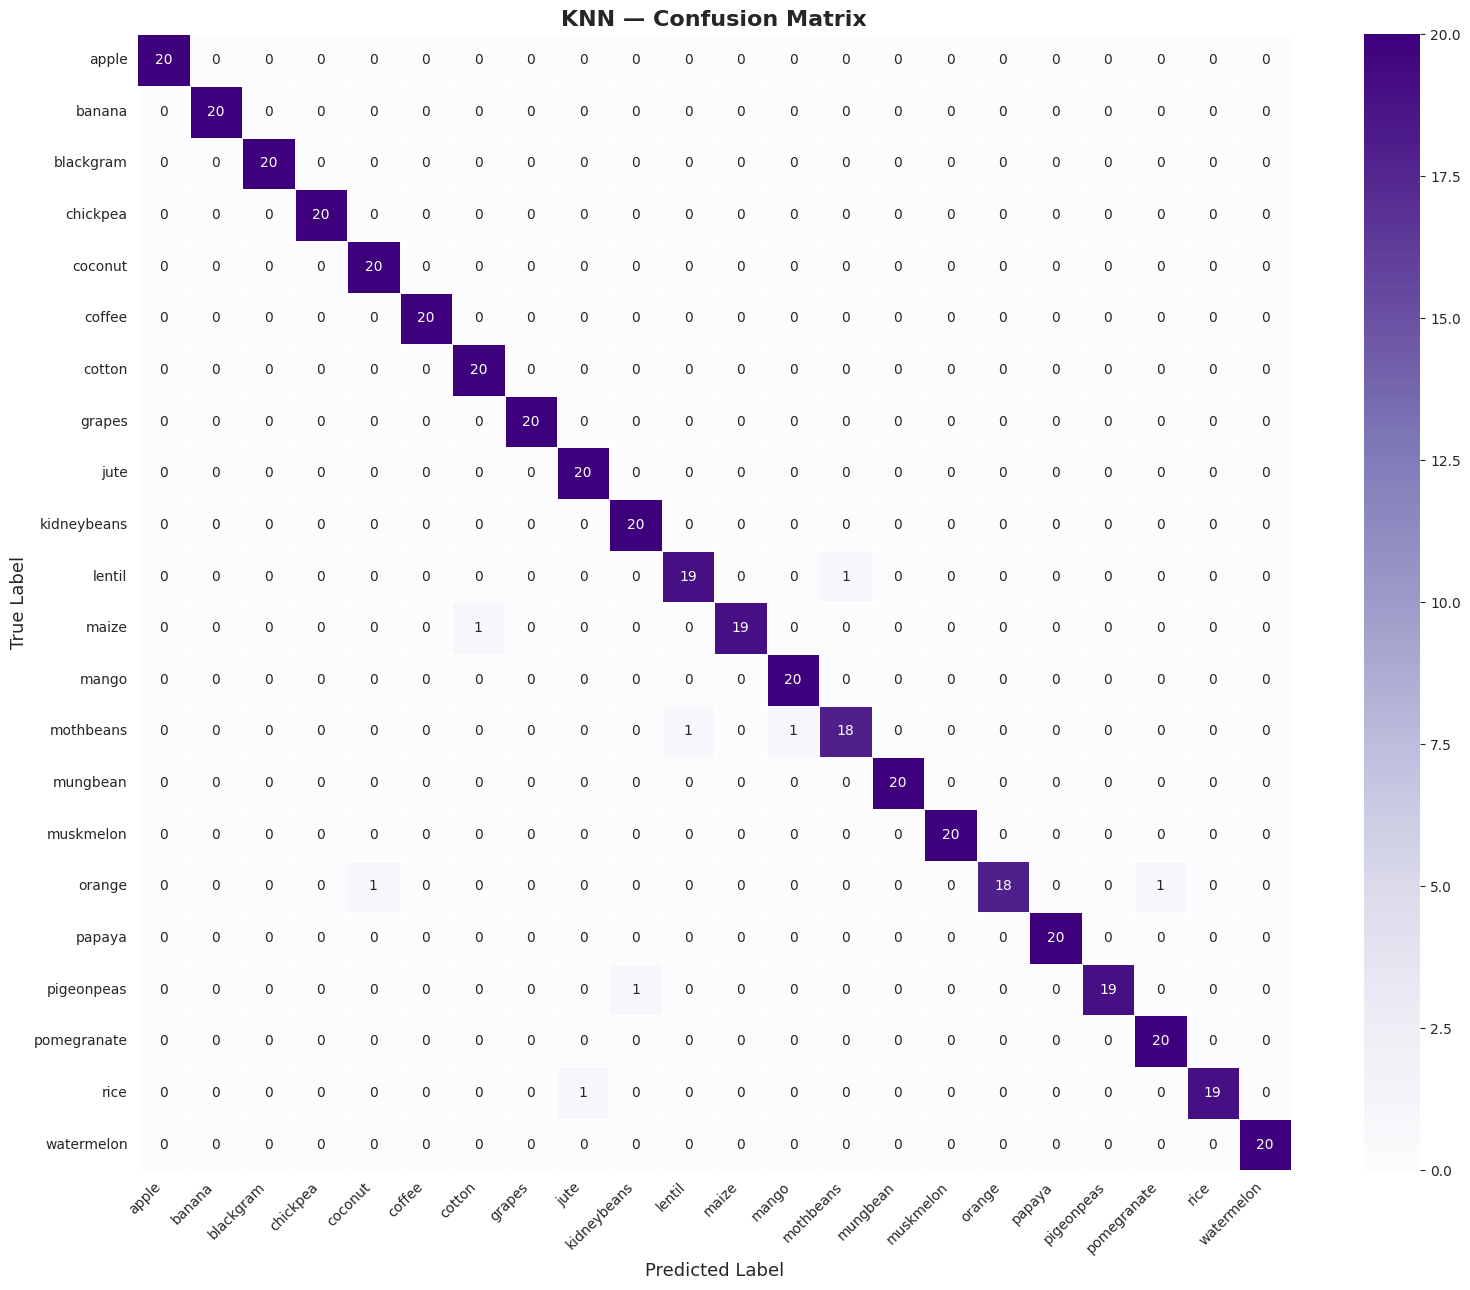

In [ ]:
# ── CELL 13 — Confusion Matrix ────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
plt.title('KNN — Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

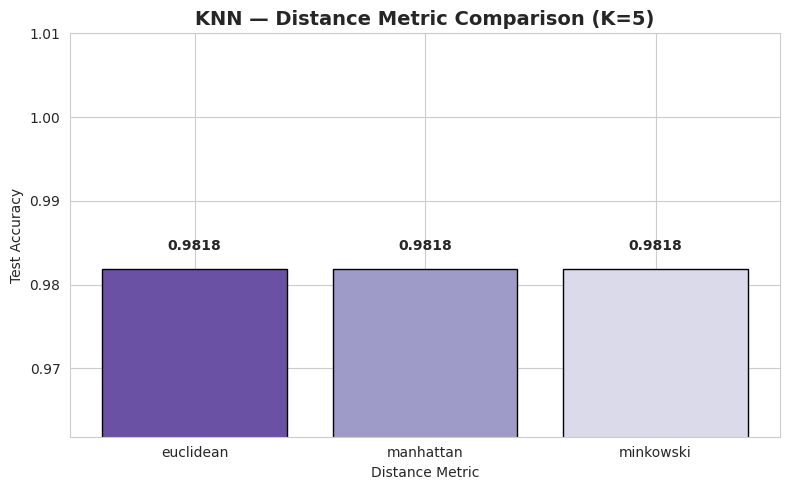

In [ ]:
# ── CELL 14 — Distance Metric Comparison ─────────────────────────────────
# Compare euclidean, manhattan, minkowski at best K
metrics_list = ['euclidean', 'manhattan', 'minkowski']
metric_accs  = []

for m in metrics_list:
    knn_tmp = KNeighborsClassifier(n_neighbors=best_knn.n_neighbors,
                                    weights=best_knn.weights, metric=m)
    knn_tmp.fit(X_train, y_train)
    metric_accs.append(accuracy_score(y_test, knn_tmp.predict(X_test)))

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_list, metric_accs,
               color=sns.color_palette('Purples_r', 3), edgecolor='black')
for bar, acc in zip(bars, metric_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title(f'KNN — Distance Metric Comparison (K={best_knn.n_neighbors})',
          fontsize=14, fontweight='bold')
plt.xlabel('Distance Metric')
plt.ylabel('Test Accuracy')
plt.ylim(min(metric_accs) - 0.02, 1.01)
plt.tight_layout()
plt.show()

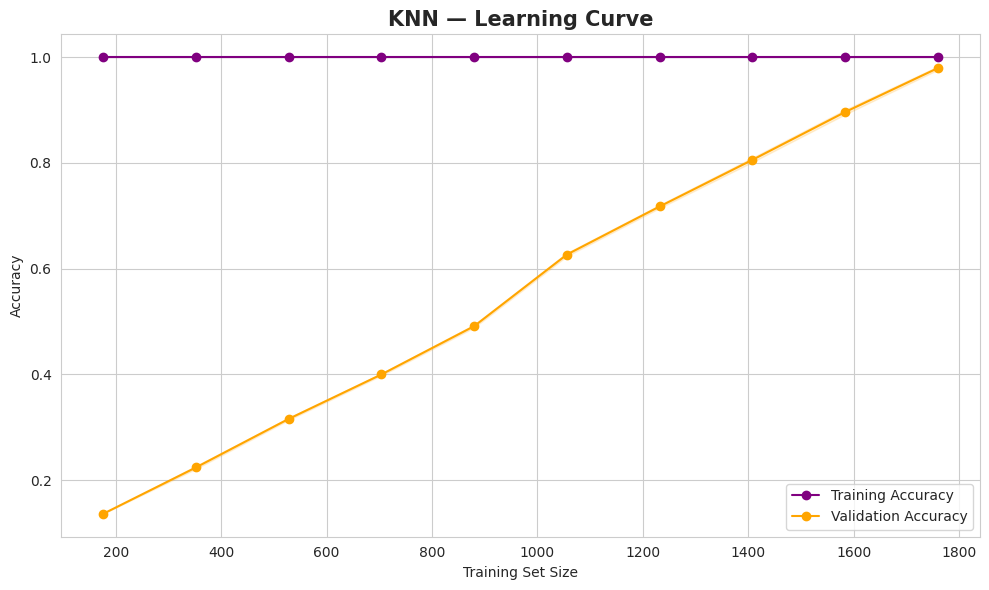

In [ ]:
# ── CELL 15 — Learning Curve ──────────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    best_knn, X_scaled, y_encoded,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='purple', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='purple')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation Accuracy')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='orange')
plt.title('KNN — Learning Curve', fontsize=15, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 16 — Metrics Summary (Save for Report Comparison) ───────────────
metrics_knn = {
    'Algorithm' : 'KNN',
    'Accuracy'  : round(accuracy, 4),
    'Precision' : round(precision, 4),
    'Recall'    : round(recall, 4),
    'F1 Score'  : round(f1, 4),
    'ROC-AUC'   : round(roc_auc, 4),
    'CV Mean'   : round(cv_scores.mean(), 4),
    'CV Std'    : round(cv_scores.std(), 4)
}

metrics_df = pd.DataFrame([metrics_knn])
print('=== Metrics Summary (copy this to your comparison notebook) ===')
print(metrics_df.to_string(index=False))

metrics_df.to_csv('metrics_knn.csv', index=False)
print('\n✅ Metrics saved to metrics_knn.csv')

=== Metrics Summary (copy this to your comparison notebook) ===
Algorithm  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV Mean  CV Std
      KNN    0.9818     0.9823  0.9818    0.9817   0.9988   0.9809  0.0076

✅ Metrics saved to metrics_knn.csv


---
## ✅ Algorithm 3 Complete!

| Metric | Value |
|--------|-------|
| Accuracy | See Cell 11 |
| Precision | See Cell 11 |
| Recall | See Cell 11 |
| F1 Score | See Cell 11 |
| ROC-AUC | See Cell 11 |

**Next:** Open `05_SVM_Colab.ipynb` for Algorithm 4 — the last one! 🔴